 8. In the lab, a classification tree was applied to the Carseats data set after converting Sales into a qualitative response variable. Now we will
 seek to predict Sales using regression trees and related approaches,
 treating the response as a quantitative variable.


(a) Split the data set into a training set and a test set.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = r"C:\Users\User-NB\OneDrive\Desktop\ml&fintech\1124\Carseats.csv"
df = pd.read_csv(path)


df.head()


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [3]:
from sklearn.model_selection import train_test_split

# 把 Sales 當 y，其餘特徵當 X
X = df.drop(columns=['Sales'])
y = df['Sales']

# 類別變數要做 one-hot，先做 train/test split 再 encoding 比較乾淨
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# 轉成 dummy variables（擴展類別欄位）
X_train = pd.get_dummies(X_train_raw, drop_first=True)
X_test  = pd.get_dummies(X_test_raw, drop_first=True)

# 保證 train / test 欄位一致（某些類別可能只出現在 train）
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train.shape, X_test.shape


((280, 11), (120, 11))

 (b) Fit a regression tree to the training set. Plot the tree, and inter
pret the results. What test MSE do you obtain?

Test MSE (unpruned tree): 6.214415833333333


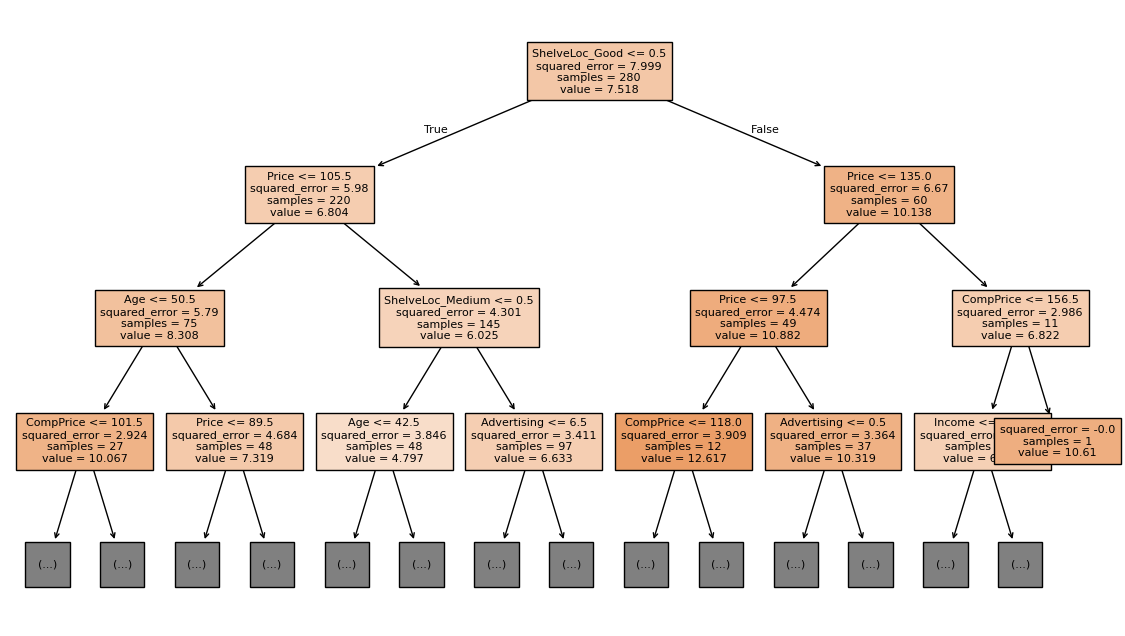

In [4]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error

tree = DecisionTreeRegressor(random_state=1)
tree.fit(X_train, y_train)

# 測試集預測
y_pred = tree.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
print("Test MSE (unpruned tree):", test_mse)

plt.figure(figsize=(14, 8))
plot_tree(
    tree,
    feature_names=X_train.columns,
    filled=True,
    max_depth=3,        # 只畫前幾層避免太亂
    fontsize=8
)
plt.show()


 (c) Use cross-validation in order to determine the optimal level of
 tree complexity. Does pruning the tree improve the test MSE?

最佳 ccp_alpha: 0.029417144557821892


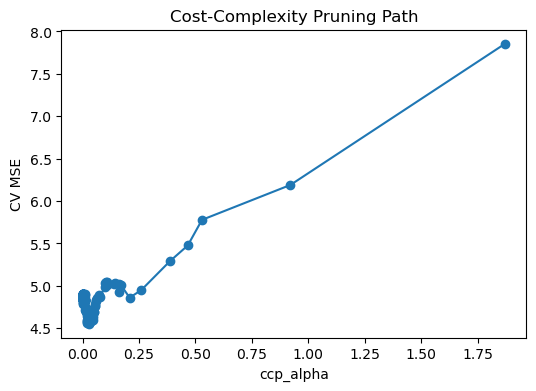

In [5]:
from sklearn.model_selection import cross_val_score

# 先計算 pruning path
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# 對每個 alpha 建一棵樹、做 CV
cv_mse_list = []

for alpha in ccp_alphas:
    clf = DecisionTreeRegressor(random_state=1, ccp_alpha=alpha)
    # 用 neg_mean_squared_error -> 取負號變成 MSE
    mse = -cross_val_score(
        clf, X_train, y_train,
        cv=10,
        scoring='neg_mean_squared_error'
    ).mean()
    cv_mse_list.append(mse)

# 找 MSE 最小的 alpha
best_alpha = ccp_alphas[np.argmin(cv_mse_list)]
print("最佳 ccp_alpha:", best_alpha)

# 畫 CV MSE vs alpha
plt.figure(figsize=(6,4))
plt.plot(ccp_alphas, cv_mse_list, marker='o')
plt.xlabel("ccp_alpha")
plt.ylabel("CV MSE")
plt.title("Cost-Complexity Pruning Path")
plt.show()


In [6]:
pruned_tree = DecisionTreeRegressor(random_state=1, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)

y_pred_pruned = pruned_tree.predict(X_test)
test_mse_pruned = mean_squared_error(y_test, y_pred_pruned)
print("Test MSE (pruned tree):", test_mse_pruned)


Test MSE (pruned tree): 5.219504927479902


 (d) Use the bagging approach in order to analyze this data. What
 test MSE do you obtain? Use the feature_importance_ values to
 determine which variables are most important.

In [7]:
from sklearn.ensemble import RandomForestRegressor

n_features = X_train.shape[1]

bagging_model = RandomForestRegressor(
    n_estimators=500,
    max_features=n_features,   # = p，等於 Bagging
    random_state=1
)
bagging_model.fit(X_train, y_train)

y_pred_bag = bagging_model.predict(X_test)
test_mse_bag = mean_squared_error(y_test, y_pred_bag)
print("Test MSE (bagging):", test_mse_bag)


Test MSE (bagging): 2.852289648966676


(e) Use random forests to analyze this data. What test MSE do
 you obtain? Use the feature_importance_ values to determine
 which variables are most important. Describe the effect of m, the
 number of variables considered at each split, on the error rate
 obtained.

In [8]:
m_list = [int(np.sqrt(n_features)), n_features // 2, n_features]
m_list


[3, 5, 11]

In [9]:
rf_results = {}

for m in m_list:
    rf = RandomForestRegressor(
        n_estimators=500,
        max_features=m,
        random_state=1
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    rf_results[m] = mse_rf
    print(f"m = {m}, Test MSE = {mse_rf:.4f}")


m = 3, Test MSE = 3.0026
m = 5, Test MSE = 2.7847
m = 11, Test MSE = 2.8523


In [10]:
m_sqrt = int(np.sqrt(n_features))
rf_sqrt = RandomForestRegressor(
    n_estimators=500,
    max_features=m_sqrt,
    random_state=1
)
rf_sqrt.fit(X_train, y_train)

feat_imp_rf = pd.Series(
    rf_sqrt.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
print(feat_imp_rf.head(10))


Price               0.235218
ShelveLoc_Good      0.172477
Age                 0.113100
Advertising         0.100960
CompPrice           0.099427
Income              0.079485
Population          0.078291
Education           0.050923
ShelveLoc_Medium    0.041601
US_Yes              0.017251
dtype: float64


 (f) Now analyze the data using BART, and report your results.

In [13]:
!pip install ISLP
